Successfully loaded assets from: C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl


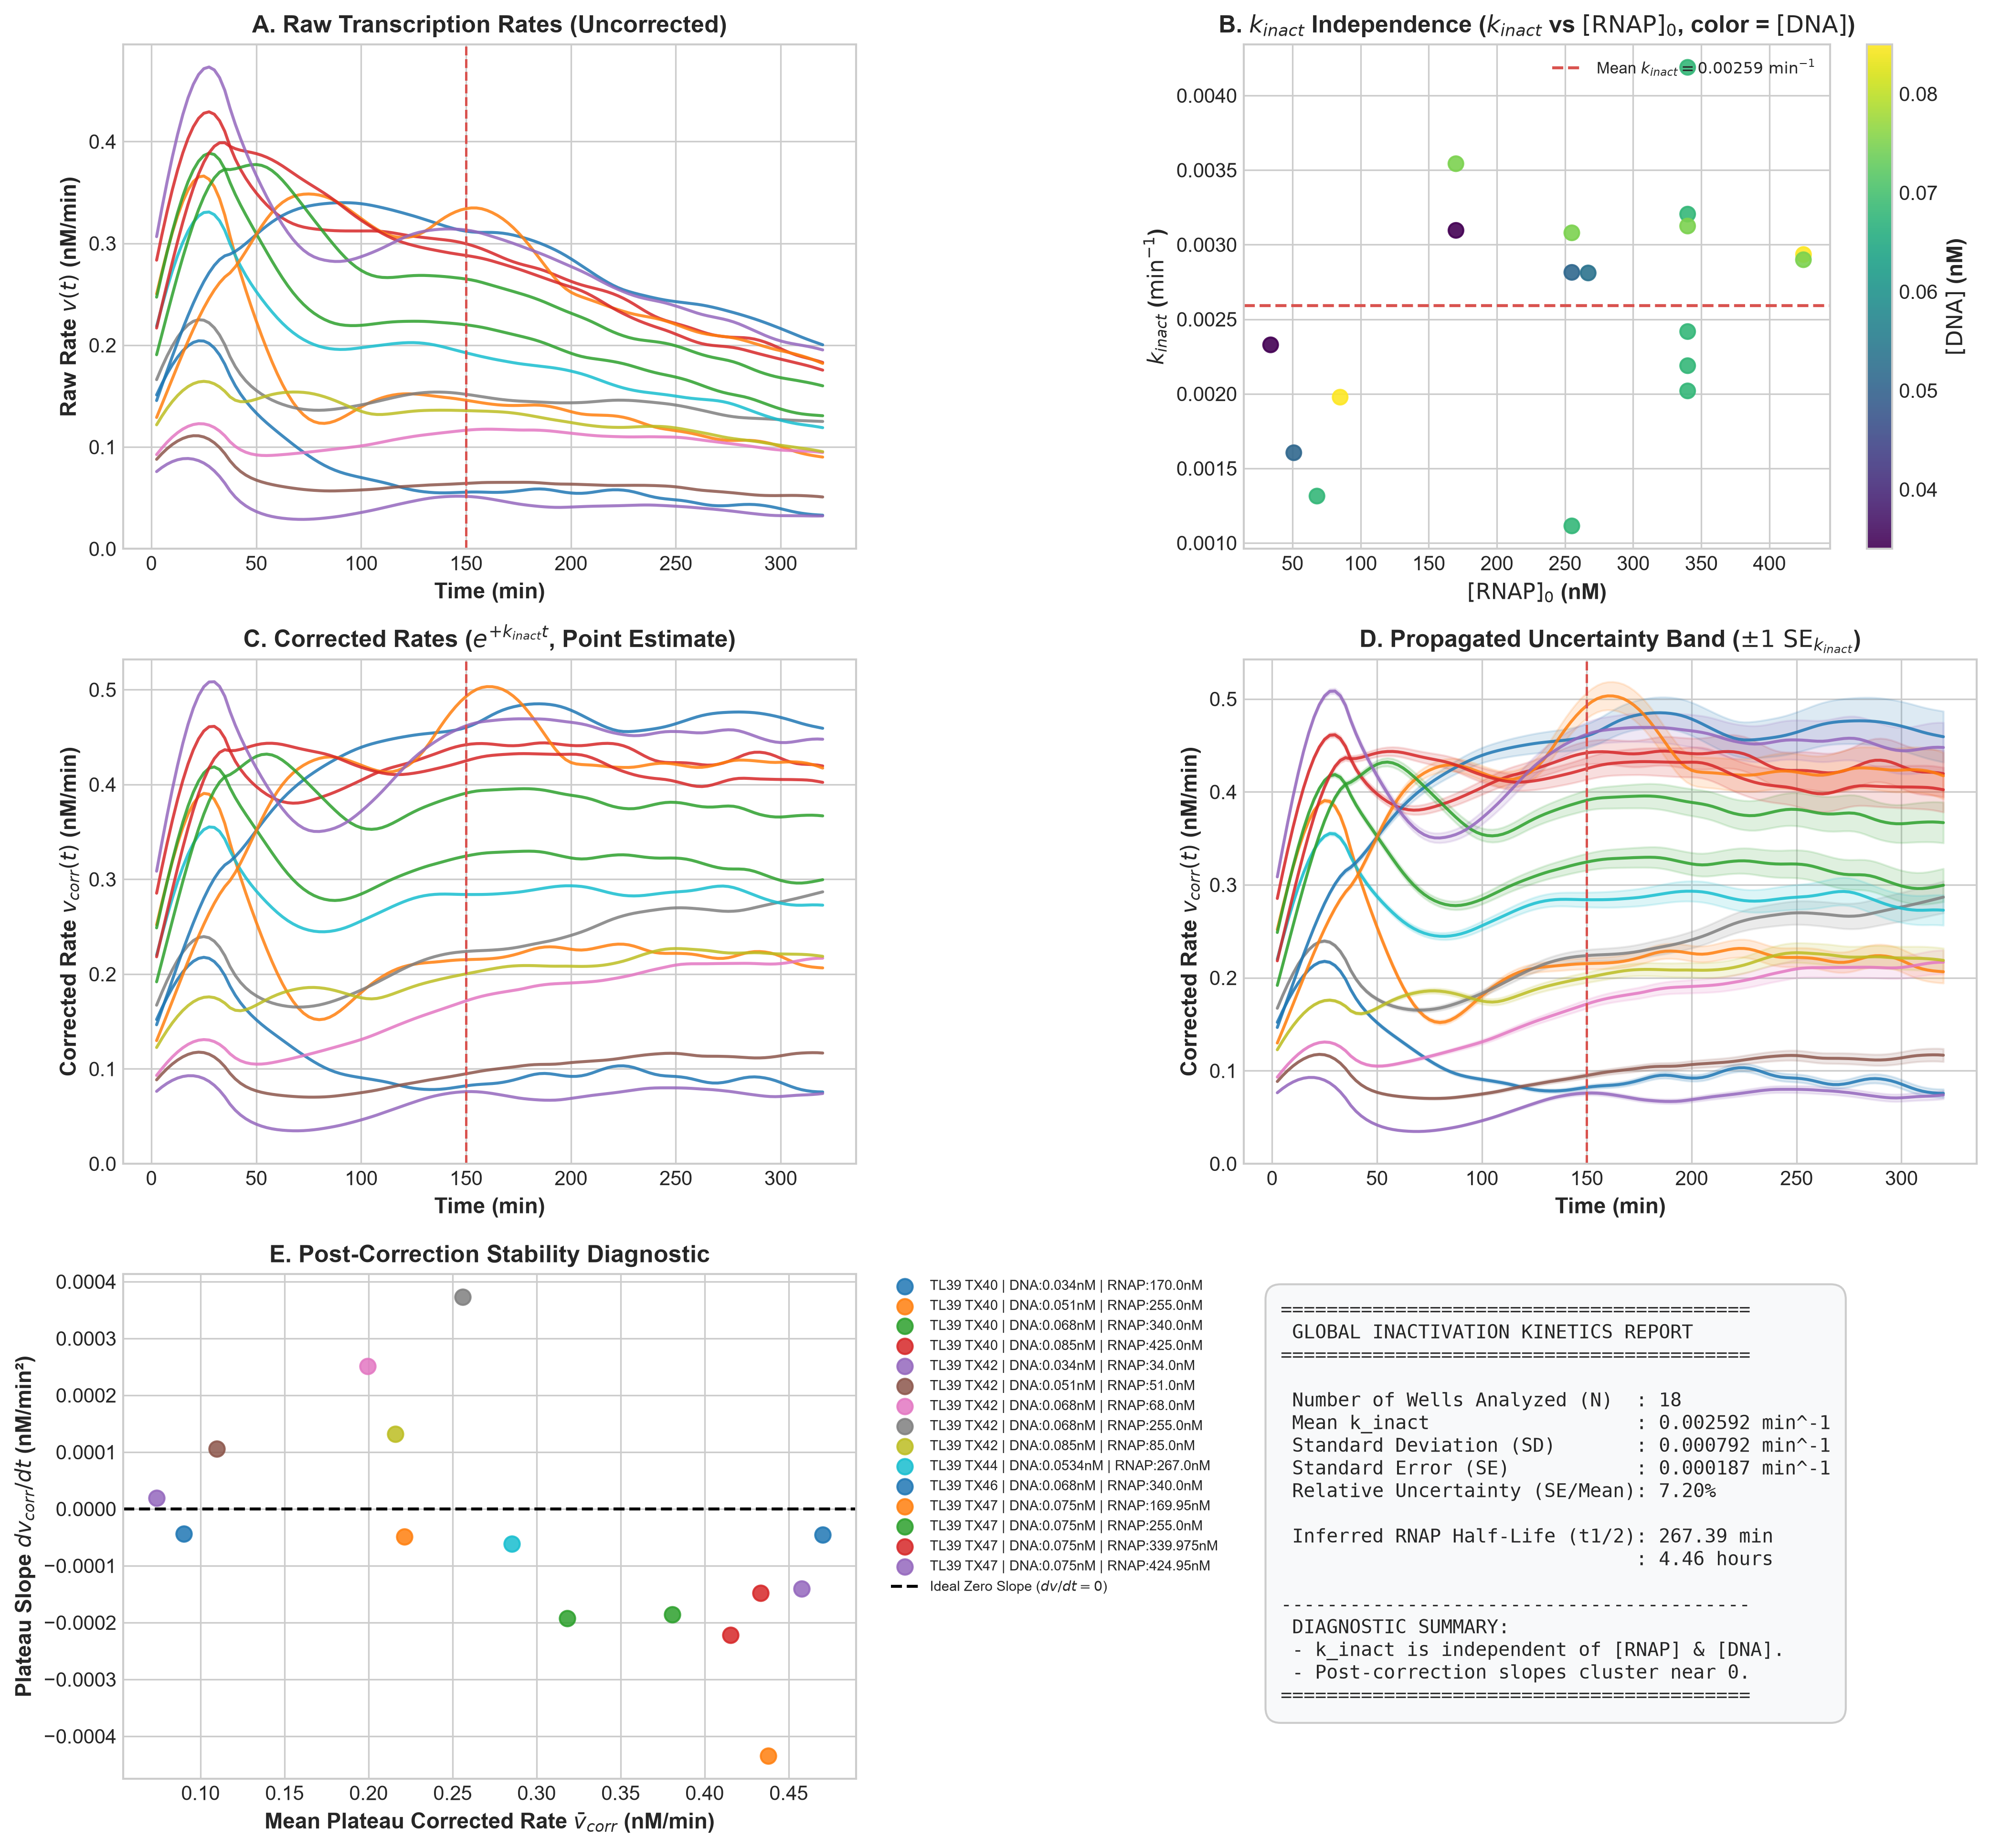

 GLOBAL RNAP FIRST-ORDER INACTIVATION & CORRECTION REPORT
 Total Evaluated Wells (N)        : 18
 Global Mean k_inact              : 0.002592 min^-1
 Standard Error (SE)              : 0.000187 min^-1 (7.20%)
 RNAP Enzyme Half-Life (t_1/2)    : 267.39 min (4.46 h)


In [34]:
"""
===============================================================================
Research Script: Global RNAP First-Order Inactivation & Correction Pipeline
===============================================================================
Description:
    1. Computes raw transcription rates v(t) per well via deconvolution.
    2. Extracts well-level inactivation rates k_inact via log-linear fit (t >= 150 min).
    3. Demonstrates independence of k_inact from [RNAP]_0 and [DNA] concentrations.
    4. Evaluates global mean k_inact and its standard error (SE).
    5. Applies exponential correction v_corr(t) = v(t) * exp(k_inact * t).
    6. Propagates uncertainty (SE of k_inact) on the corrected rates.
    7. Evaluates post-correction plateau slopes vs mean rates against ideal line (y=0).
===============================================================================
"""

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

# Local deconvolution utility imports
sys.path.append(r"C:\Users\ForzaPC\Desktop\repo\notebooks")
from util.deconvolution_utils import (
    load_deconvolution_assets,
    compute_instantaneous_rate
)

# -----------------------------------------------------------------------------
# 0. Global Matplotlib & Plot Configuration
# -----------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    'font.size': 10, 'font.sans-serif': 'Arial', 'font.family': 'sans-serif',
    'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.dpi': 300,
    'pdf.fonttype': 42, 'ps.fonttype': 42
})

# -----------------------------------------------------------------------------
# 1. Hyperparameters & File Paths
# -----------------------------------------------------------------------------
LAMBDA_REG = 0.5            # Tikhonov regularization factor
WINDOW_MIN = 65          # Savitzky-Golay integration window (min)
T_PLATEAU_START = 150.0     # Start of decay/plateau evaluation window (min)
T_PLOT_MAX = 320.0          # Maximum time boundary for evaluation/plotting (min)

data_path = Path(r"C:\Users\ForzaPC\Desktop\repo\data\raw_TX\TX_cleaned_data.csv")
assets_path = Path(r"C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl")

# -----------------------------------------------------------------------------
# 2. Data Loading & Sanitization
# -----------------------------------------------------------------------------
df = pd.read_csv(data_path)
_, f_kernel, alpha_slope, DT_MIN = load_deconvolution_assets(assets_path)

df["DNA Template"] = df["DNA Template"].astype(str).str.strip()
df["Exp_ID"] = df["Exp_ID"].astype(str).str.strip()
df["Well"] = df["Well"].astype(str).str.strip()
df["TopoI (U)"] = df["TopoI (U)"].fillna(0)
df["Gyr (U)"] = df["Gyr (U)"].fillna(0)
df["time_min"] = df["Cycle"] * DT_MIN

# Filter target conditions: RX template, TopoI = 0 U, Gyrase = 0 U
rx_df = df[
    (df["DNA Template"].str.contains("RX", case=False, na=False)) &
    (df["TopoI (U)"] == 0) &
    (df["Gyr (U)"] == 0)
].copy()

# -----------------------------------------------------------------------------
# 3. Well-Level Deconvolution & Individual k_inact Extraction
# -----------------------------------------------------------------------------
well_results = []
condition_cols = ["Exp_ID", "DNA Template", "[DNA] (nM)", "[RNAP] (nM)"]
cond_data = {}

for cond_keys, group in rx_df.groupby(condition_cols):
    exp_id, dna_temp, dna_conc, rnap_conc = cond_keys
    cond_label = f"{exp_id} | DNA:{dna_conc}nM | RNAP:{rnap_conc}nM"
    
    well_rates = {}
    time_vector = None
    
    for well, well_group in group.groupby("Well"):
        well_group = well_group.sort_values("Cycle")
        rfu_signal = well_group["RFU"].values
        
        if time_vector is None:
            time_vector = well_group["time_min"].values
            
        _, v_rate = compute_instantaneous_rate(
            rfu_signal=rfu_signal,
            f_kernel=f_kernel,
            alpha_slope=alpha_slope,
            dt_min=DT_MIN,
            lambda_reg=LAMBDA_REG,
            window_min=WINDOW_MIN,
            polyorder=2,
            mode="nearest"
        )
        well_rates[well] = v_rate
        
        # Fit k_inact per well via log-linear regression: ln(v(t)) = ln(v0) - k_inact * t
        fit_mask = (time_vector >= T_PLATEAU_START) & (time_vector <= T_PLOT_MAX)
        t_fit = time_vector[fit_mask]
        v_fit = np.maximum(v_rate[fit_mask], 1e-6)
        
        slope, intercept, r_val, p_val, std_err = stats.linregress(t_fit, np.log(v_fit))
        k_inact_well = -slope
        
        if k_inact_well > 0 and not np.isnan(k_inact_well):
            well_results.append({
                "Well": well,
                "Cond_Label": cond_label,
                "RNAP": rnap_conc,
                "DNA": dna_conc,
                "k_inact": k_inact_well
            })
            
    if not well_rates:
        continue
        
    matrix_v = np.array(list(well_rates.values()))
    cond_data[cond_label] = {
        "rnap_conc": rnap_conc,
        "dna_conc": dna_conc,
        "time_vector": time_vector,
        "matrix_v": matrix_v,
        "mean_v": np.mean(matrix_v, axis=0),
        "std_v": np.std(matrix_v, axis=0, ddof=1) if matrix_v.shape[0] > 1 else np.zeros(matrix_v.shape[1])
    }

df_wells = pd.DataFrame(well_results)

# -----------------------------------------------------------------------------
# 4. Global Inactivation Statistics & Error Propagation
# -----------------------------------------------------------------------------
k_inact_mean = df_wells["k_inact"].mean()
k_inact_std = df_wells["k_inact"].std(ddof=1)
k_inact_se = stats.sem(df_wells["k_inact"])
n_wells = len(df_wells)

# -----------------------------------------------------------------------------
# 5. Diagnostic Figure Generation (6 Panels)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

# --- PANEL A: Raw Transcription Rates ---
for cond_label, info in cond_data.items():
    t_plot = info["time_vector"][info["time_vector"] <= T_PLOT_MAX]
    v_plot = info["mean_v"][info["time_vector"] <= T_PLOT_MAX]
    axes[0, 0].plot(t_plot, v_plot, lw=1.5, alpha=0.85, label=cond_label)

axes[0, 0].axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
axes[0, 0].set_xlabel("Time (min)", fontweight="bold")
axes[0, 0].set_ylabel("Raw Rate $v(t)$ (nM/min)", fontweight="bold")
axes[0, 0].set_title("A. Raw Transcription Rates (Uncorrected)", fontweight="bold")
axes[0, 0].set_ylim(bottom=0)

# --- PANEL B: Independence of k_inact vs [RNAP]0 and [DNA] ---
sc1 = axes[0, 1].scatter(df_wells["RNAP"], df_wells["k_inact"], c=df_wells["DNA"], cmap="viridis", s=55, alpha=0.9)
axes[0, 1].axhline(k_inact_mean, color="#d9534f", linestyle="--", lw=1.5, label=f"Mean $k_{{inact}} = {k_inact_mean:.5f}\\ \\mathrm{{min}}^{{-1}}$")
axes[0, 1].set_xlabel(r"$[\mathrm{RNAP}]_0$ (nM)", fontweight="bold")
axes[0, 1].set_ylabel(r"$k_{inact}$ ($\mathrm{min}^{-1}$)", fontweight="bold")
axes[0, 1].set_title(r"B. $k_{inact}$ Independence ($k_{inact}$ vs $[\mathrm{RNAP}]_0$, color = $[\mathrm{DNA}]$)", fontweight="bold")
cbar1 = fig.colorbar(sc1, ax=axes[0, 1])
cbar1.set_label(r"$[\mathrm{DNA}]$ (nM)", fontweight="bold")
axes[0, 1].legend(loc="upper right", fontsize=8)

# --- PANEL C: Corrected Rates (Mean k_inact, No Error Band) ---
for cond_label, info in cond_data.items():
    t_plot = info["time_vector"][info["time_vector"] <= T_PLOT_MAX]
    v_corr = info["mean_v"] * np.exp(k_inact_mean * info["time_vector"])
    axes[1, 0].plot(t_plot, v_corr[info["time_vector"] <= T_PLOT_MAX], lw=1.5, alpha=0.85, label=cond_label)

axes[1, 0].axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
axes[1, 0].set_xlabel("Time (min)", fontweight="bold")
axes[1, 0].set_ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)", fontweight="bold")
axes[1, 0].set_title(r"C. Corrected Rates ($e^{+k_{inact} t}$, Point Estimate)", fontweight="bold")
axes[1, 0].set_ylim(bottom=0)

# --- PANEL D: Corrected Rates with Propagated Uncertainty ---
for cond_label, info in cond_data.items():
    t_mask = info["time_vector"] <= T_PLOT_MAX
    t_plot = info["time_vector"][t_mask]
    v_mean = info["mean_v"][t_mask]
    
    v_corr = v_mean * np.exp(k_inact_mean * t_plot)
    v_corr_err = v_mean * t_plot * np.exp(k_inact_mean * t_plot) * k_inact_se
    
    line = axes[1, 1].plot(t_plot, v_corr, lw=1.5, alpha=0.85, label=cond_label)[0]
    axes[1, 1].fill_between(
        t_plot,
        np.maximum(v_corr - v_corr_err, 0),
        v_corr + v_corr_err,
        color=line.get_color(),
        alpha=0.15
    )

axes[1, 1].axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
axes[1, 1].set_xlabel("Time (min)", fontweight="bold")
axes[1, 1].set_ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)", fontweight="bold")
axes[1, 1].set_title(r"D. Propagated Uncertainty Band ($\pm 1\ \mathrm{SE}_{k_{inact}}$)", fontweight="bold")
axes[1, 1].set_ylim(bottom=0)

# --- PANEL E: Diagnostic Slope Diagnostic vs Mean Plateau Rate ---
diag_slopes = []
diag_means = []

for cond_label, info in cond_data.items():
    t_vec = info["time_vector"]
    v_corr = info["mean_v"] * np.exp(k_inact_mean * t_vec)
    
    plat_mask = (t_vec >= T_PLATEAU_START) & (t_vec <= T_PLOT_MAX)
    t_plat = t_vec[plat_mask]
    v_plat = v_corr[plat_mask]
    
    slope_corr, _, _, _, _ = stats.linregress(t_plat, v_plat)
    mean_plat_rate = np.mean(v_plat)
    
    diag_slopes.append(slope_corr)
    diag_means.append(mean_plat_rate)
    
    axes[2, 0].scatter(mean_plat_rate, slope_corr, s=60, alpha=0.85, label=cond_label)

axes[2, 0].axhline(0, color="black", linestyle="--", lw=1.5, label="Ideal Zero Slope ($dv/dt = 0$)")
axes[2, 0].set_xlabel("Mean Plateau Corrected Rate $\\bar{v}_{corr}$ (nM/min)", fontweight="bold")
axes[2, 0].set_ylabel("Plateau Slope $dv_{corr}/dt$ (nM/min²)", fontweight="bold")
axes[2, 0].set_title("E. Post-Correction Stability Diagnostic", fontweight="bold")
axes[2, 0].legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=7)

# --- PANEL F: Summary & Statistical Report Plot ---
axes[2, 1].axis("off")
report_text = (
    "=========================================\n"
    " GLOBAL INACTIVATION KINETICS REPORT\n"
    "=========================================\n\n"
    f" Number of Wells Analyzed (N)  : {n_wells}\n"
    f" Mean k_inact                  : {k_inact_mean:.6f} min^-1\n"
    f" Standard Deviation (SD)       : {k_inact_std:.6f} min^-1\n"
    f" Standard Error (SE)           : {k_inact_se:.6f} min^-1\n"
    f" Relative Uncertainty (SE/Mean): {(k_inact_se / k_inact_mean) * 100:.2f}%\n\n"
    f" Inferred RNAP Half-Life (t1/2): {np.log(2) / k_inact_mean:.2f} min\n"
    f"                               : {(np.log(2) / k_inact_mean) / 60:.2f} hours\n\n"
    "-----------------------------------------\n"
    " DIAGNOSTIC SUMMARY:\n"
    " - k_inact is independent of [RNAP] & [DNA].\n"
    " - Post-correction slopes cluster near 0.\n"
    "========================================="
)
axes[2, 1].text(0.05, 0.95, report_text, transform=axes[2, 1].transAxes, fontsize=9.5,
                family="monospace", verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#ccc"))

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. Console Report Output
# -----------------------------------------------------------------------------
print("=" * 80)
print(" GLOBAL RNAP FIRST-ORDER INACTIVATION & CORRECTION REPORT")
print("=" * 80)
print(f" Total Evaluated Wells (N)        : {n_wells}")
print(f" Global Mean k_inact              : {k_inact_mean:.6f} min^-1")
print(f" Standard Error (SE)              : {k_inact_se:.6f} min^-1 ({(k_inact_se / k_inact_mean) * 100:.2f}%)")
print(f" RNAP Enzyme Half-Life (t_1/2)    : {np.log(2) / k_inact_mean:.2f} min ({(np.log(2) / k_inact_mean) / 60:.2f} h)")
print("=" * 80)

Successfully loaded assets from: C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl


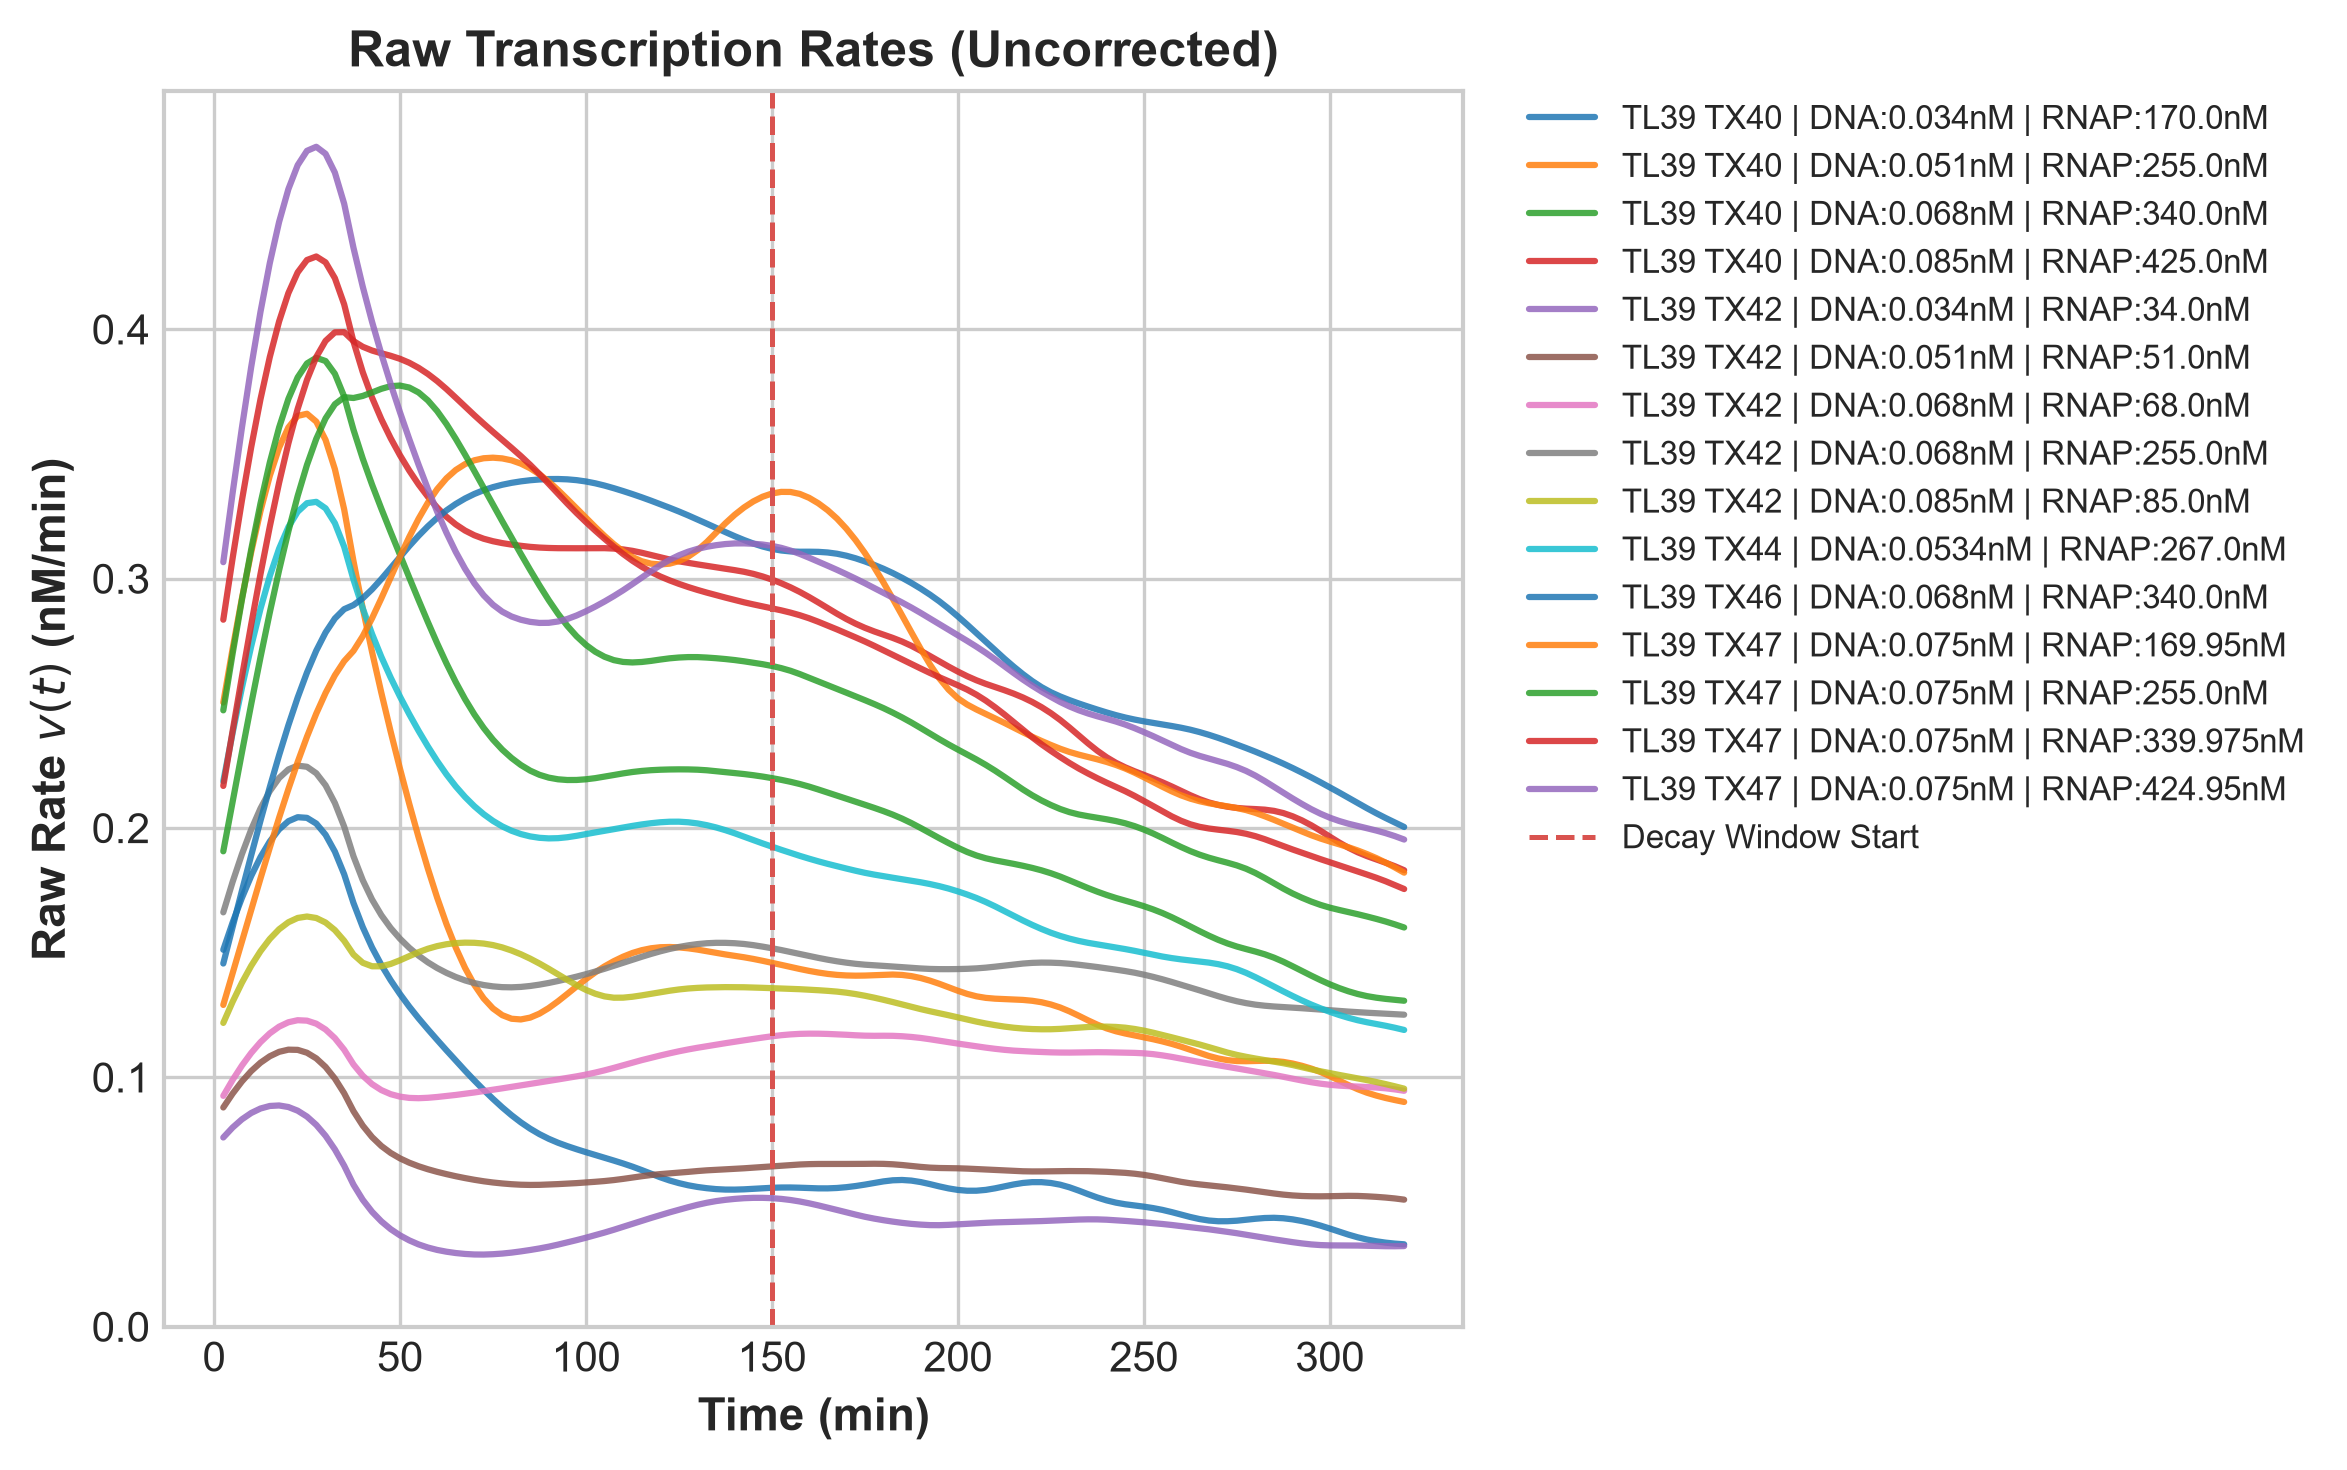

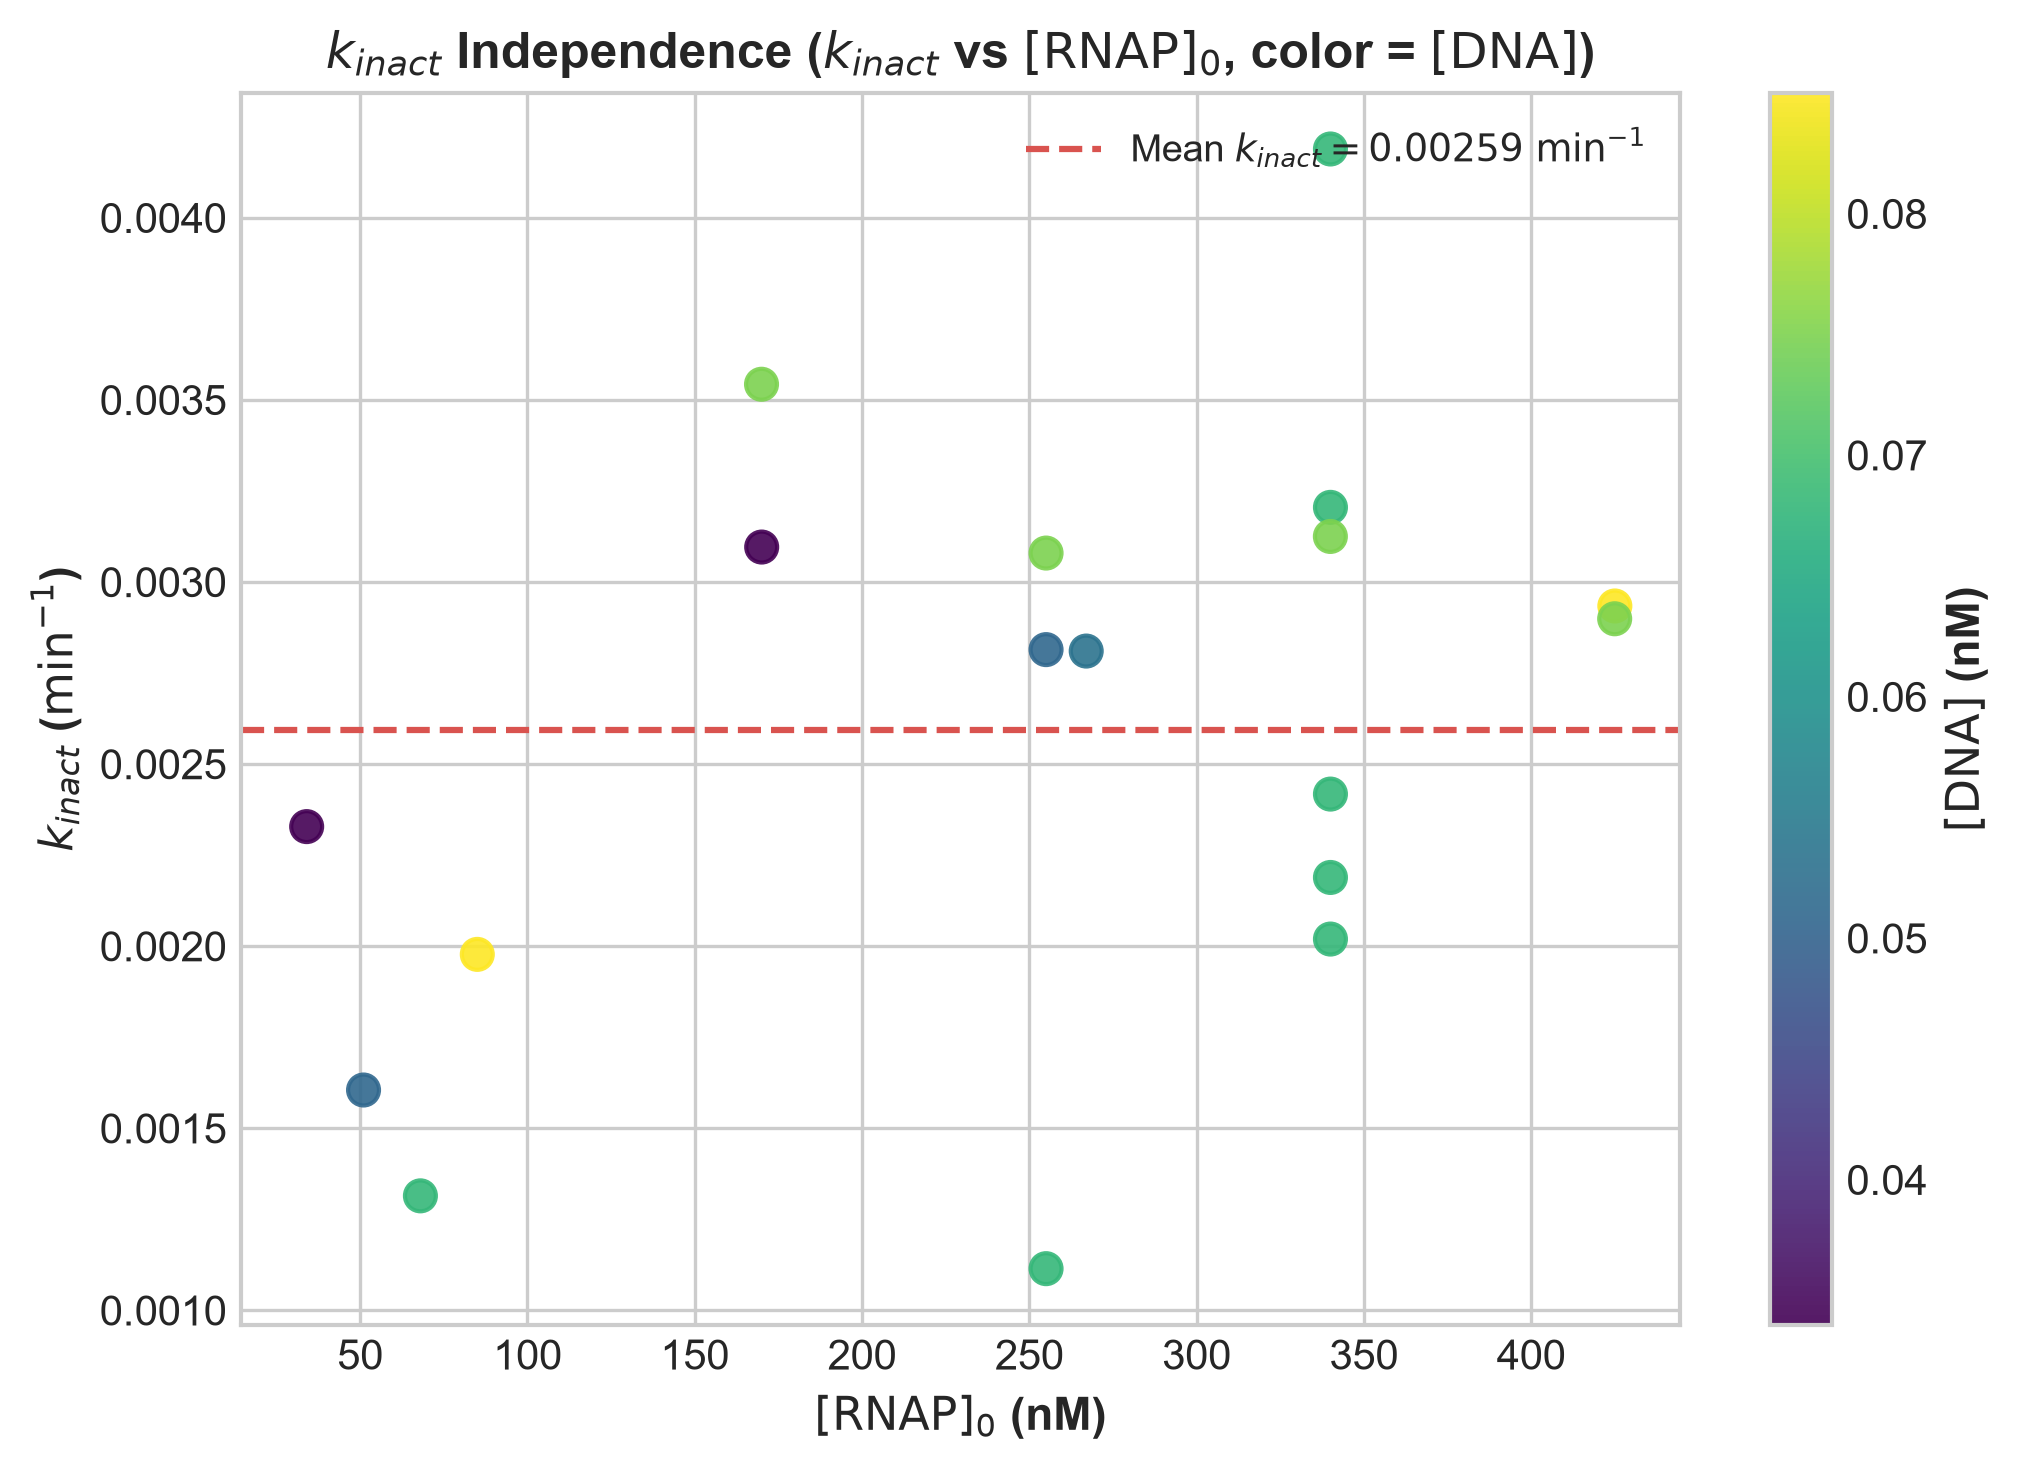

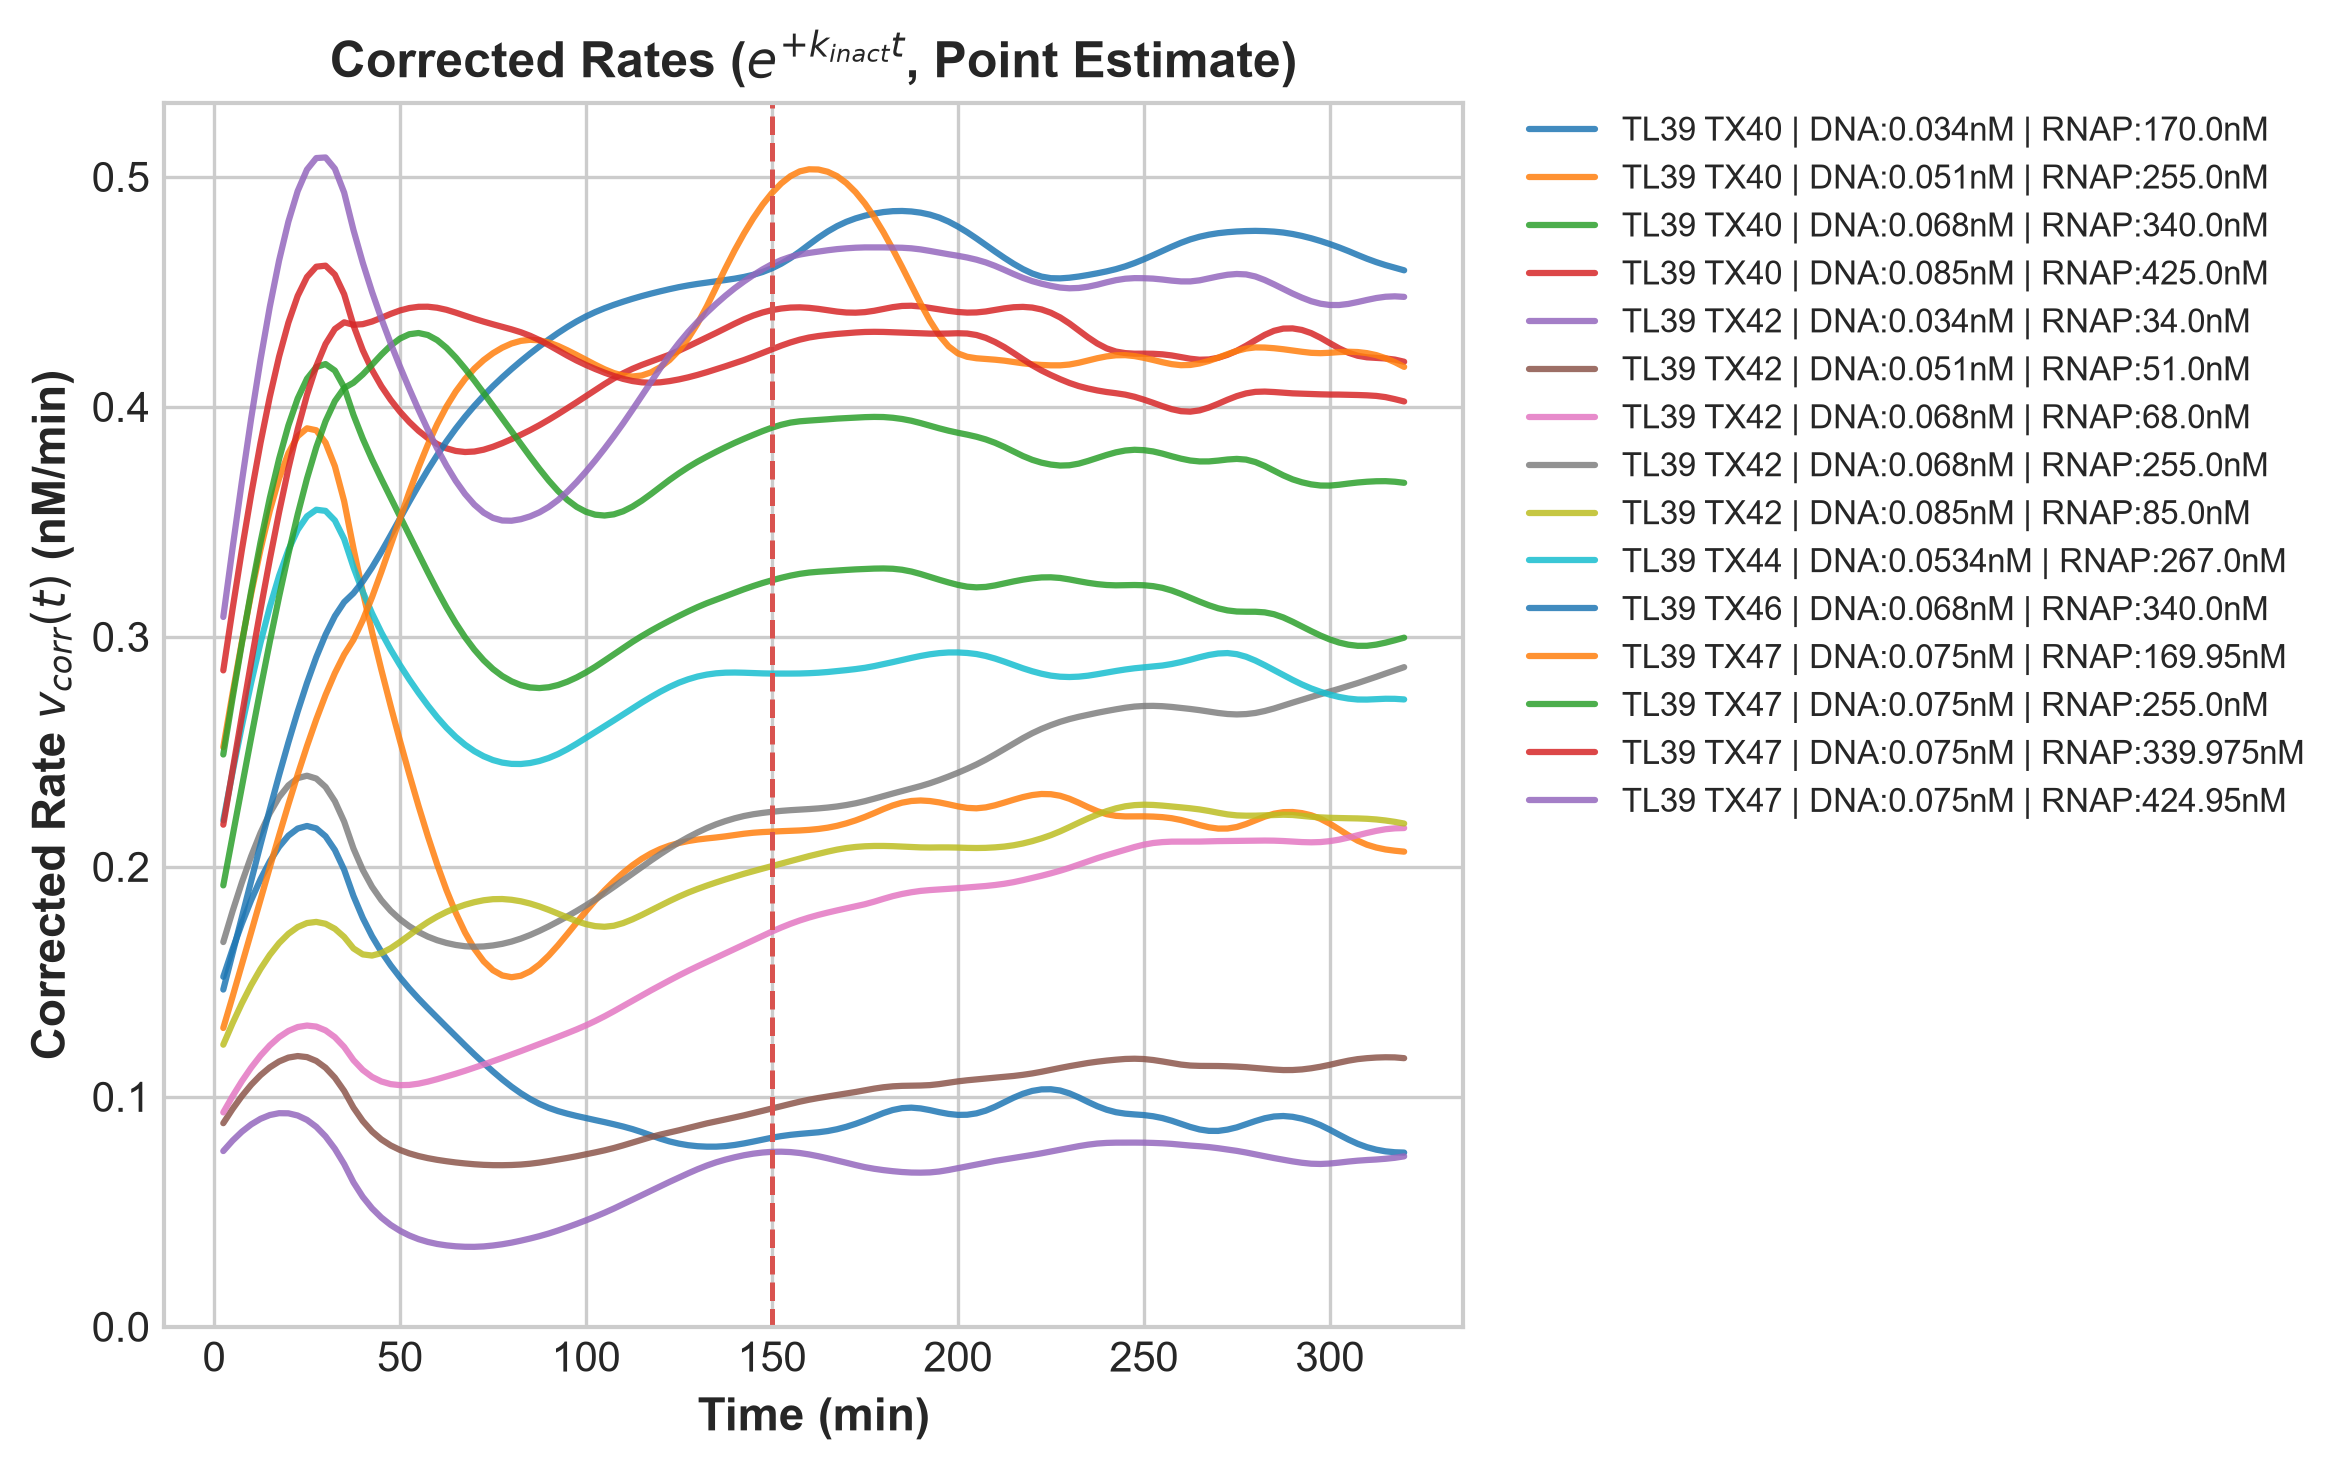

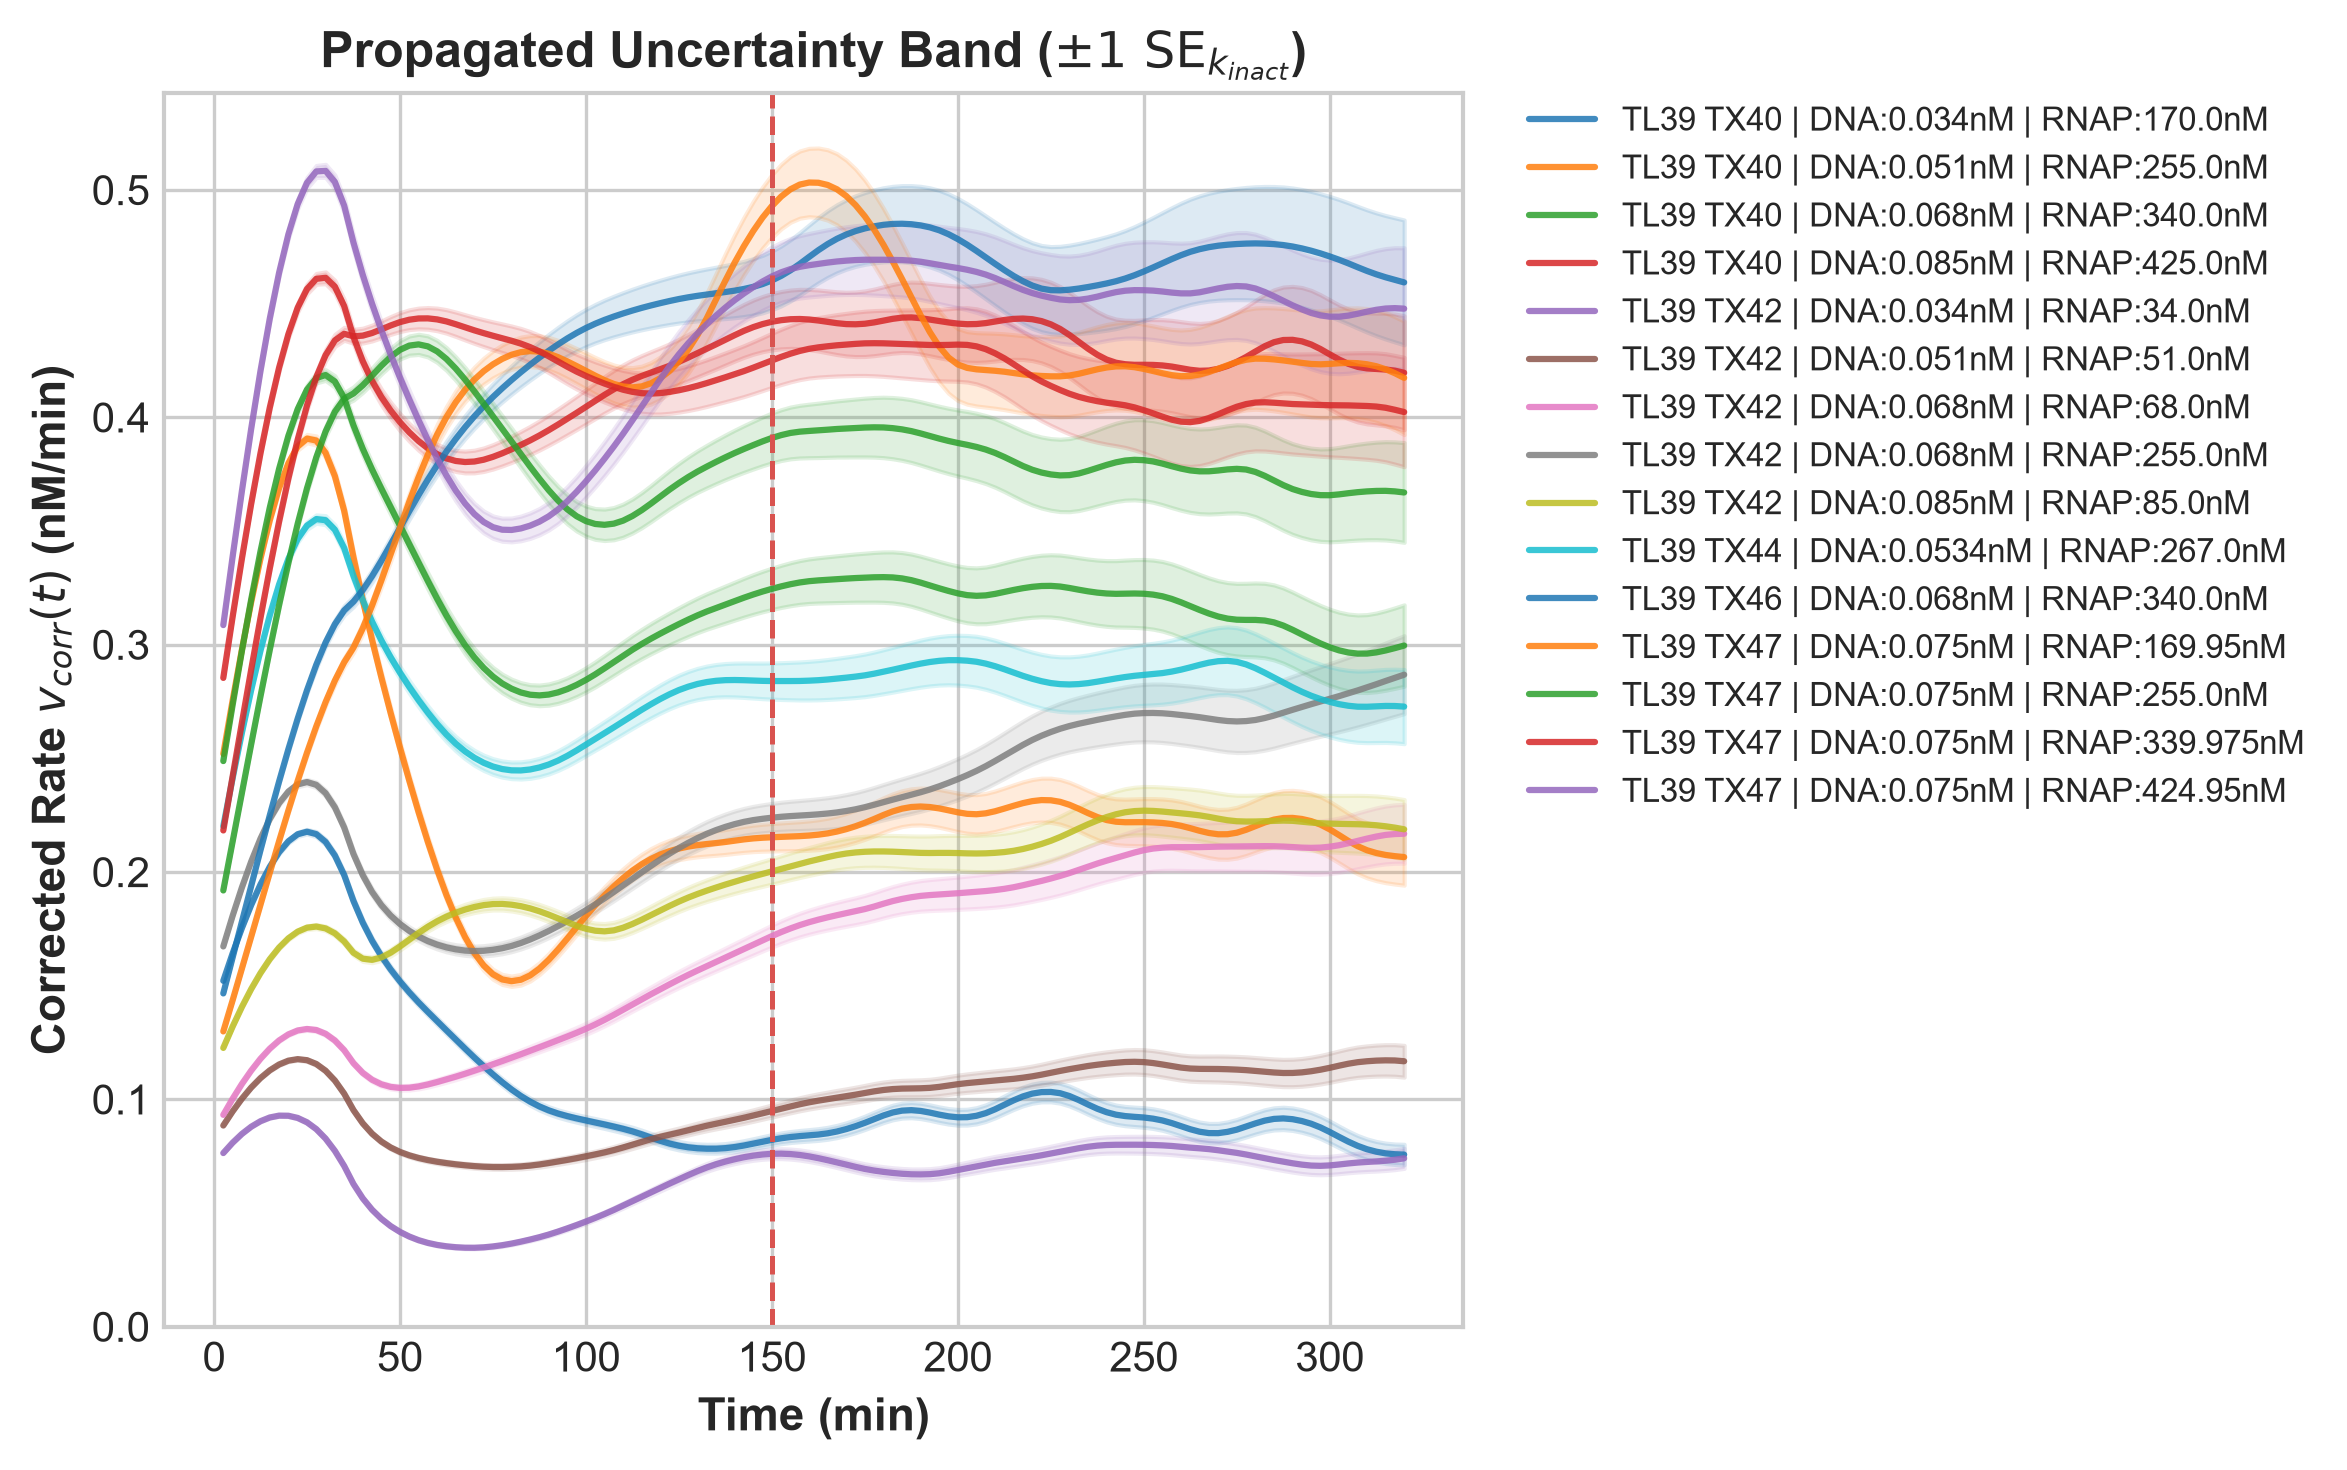

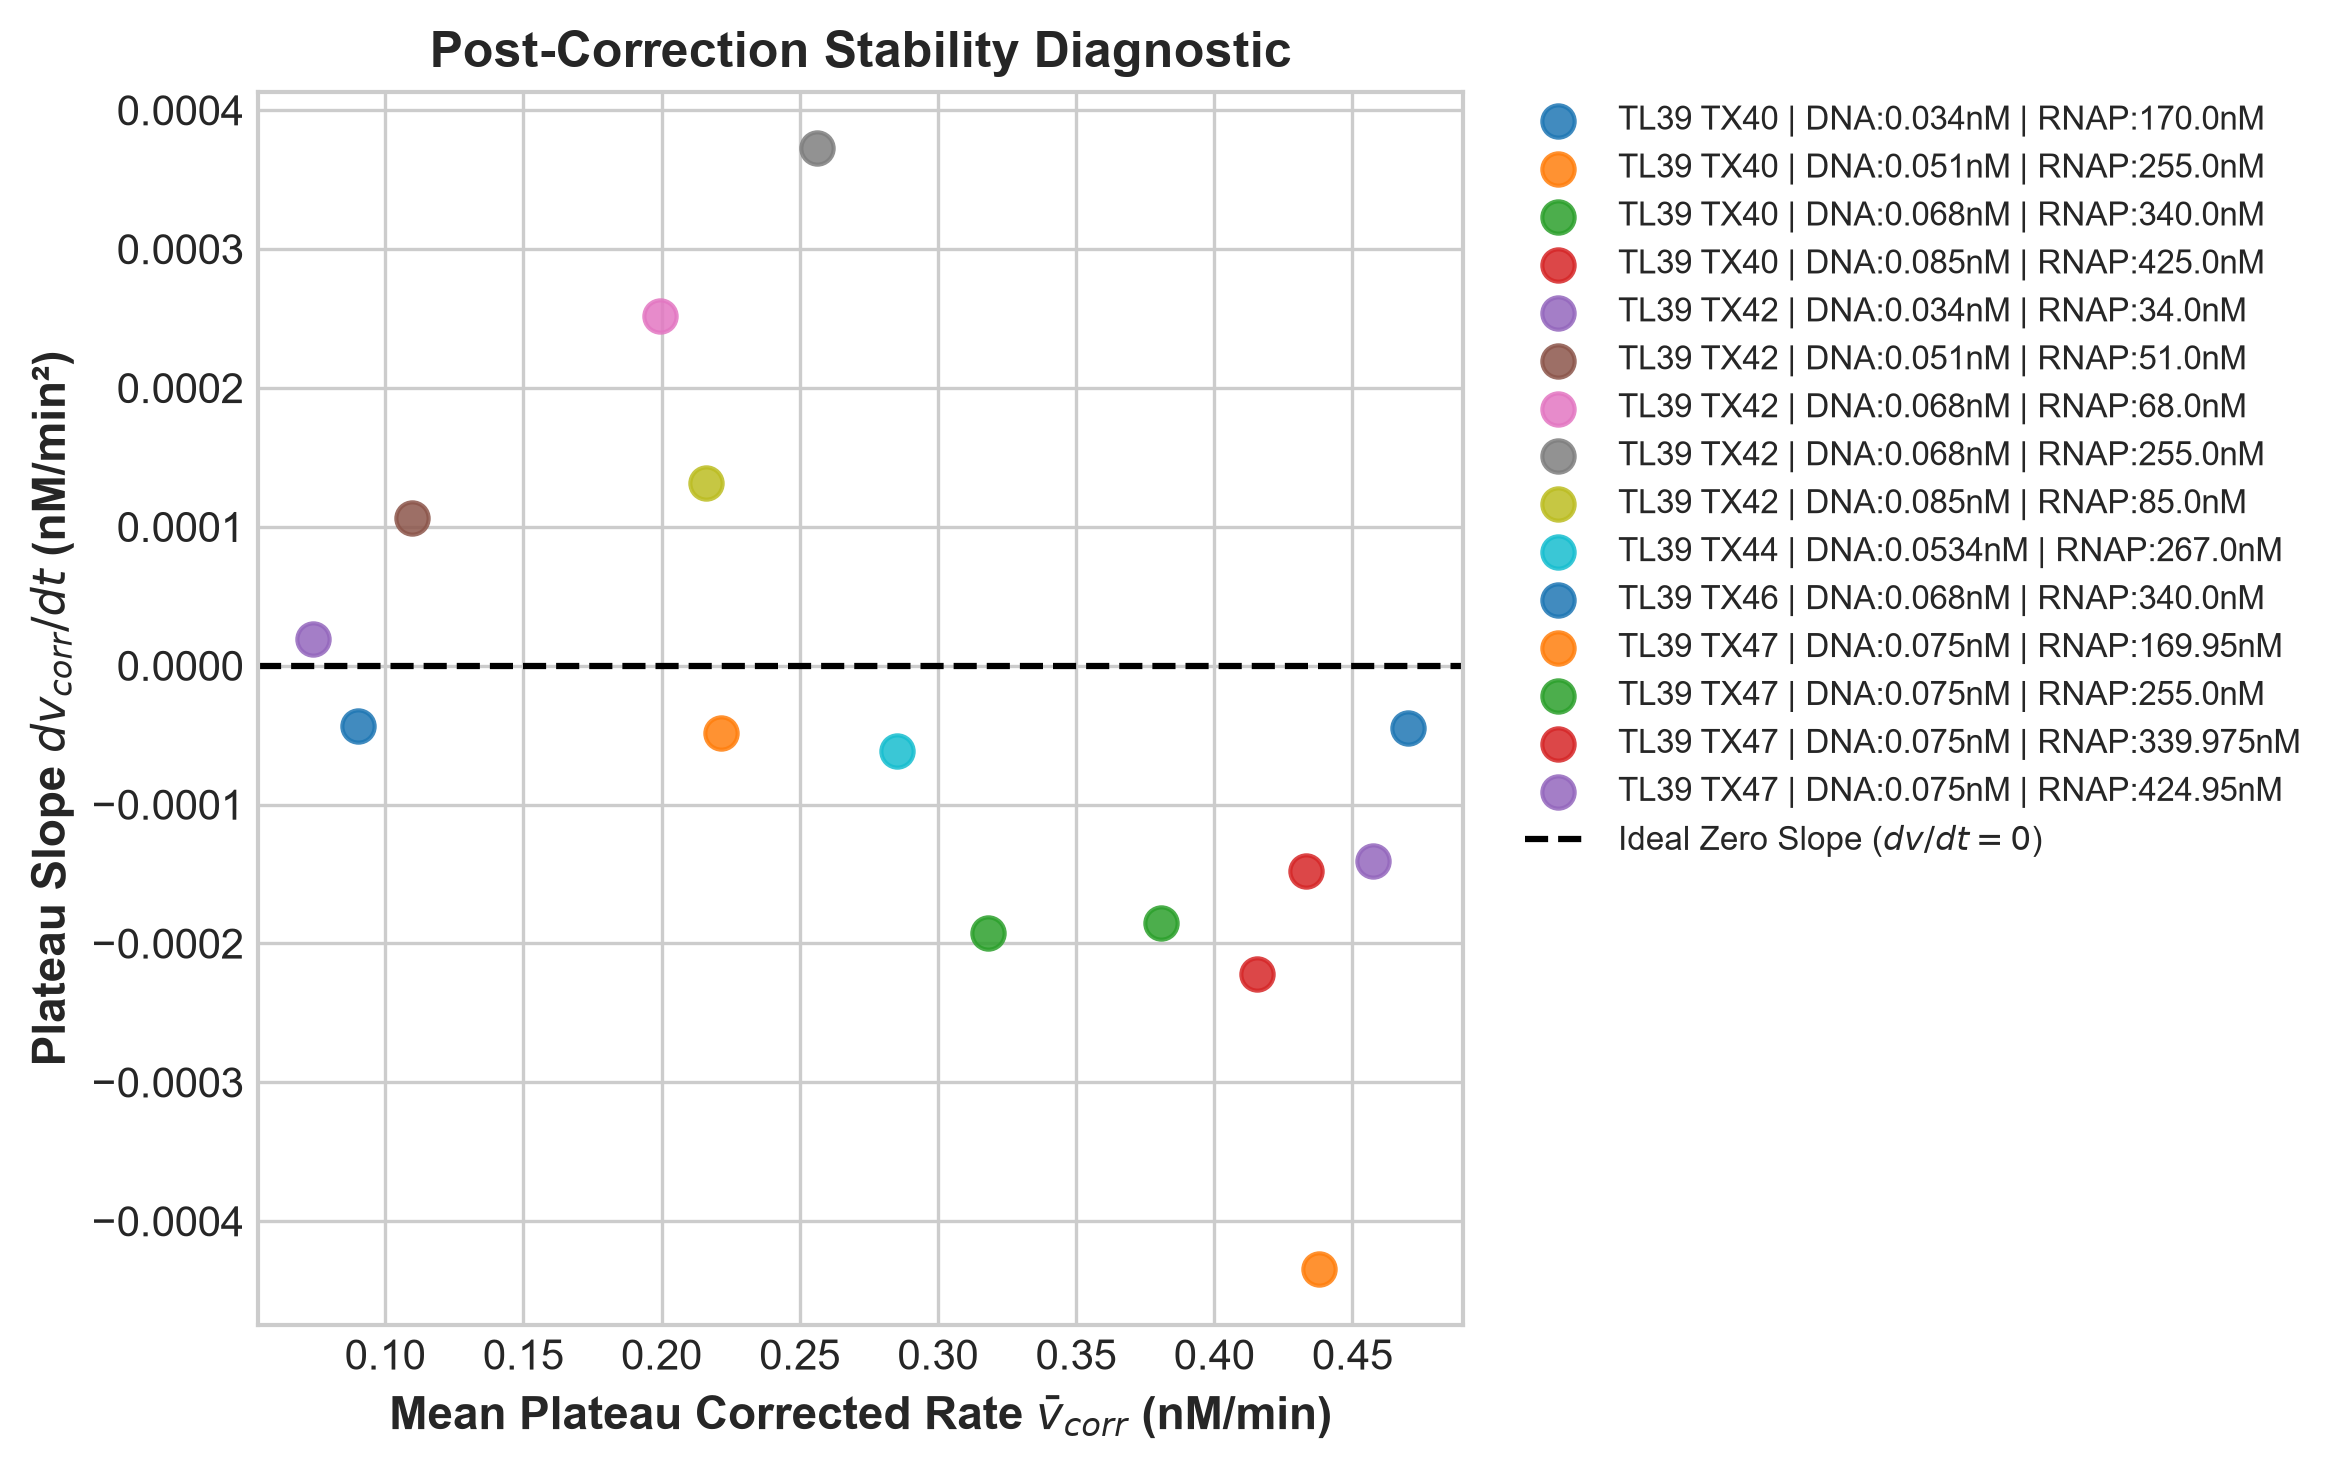

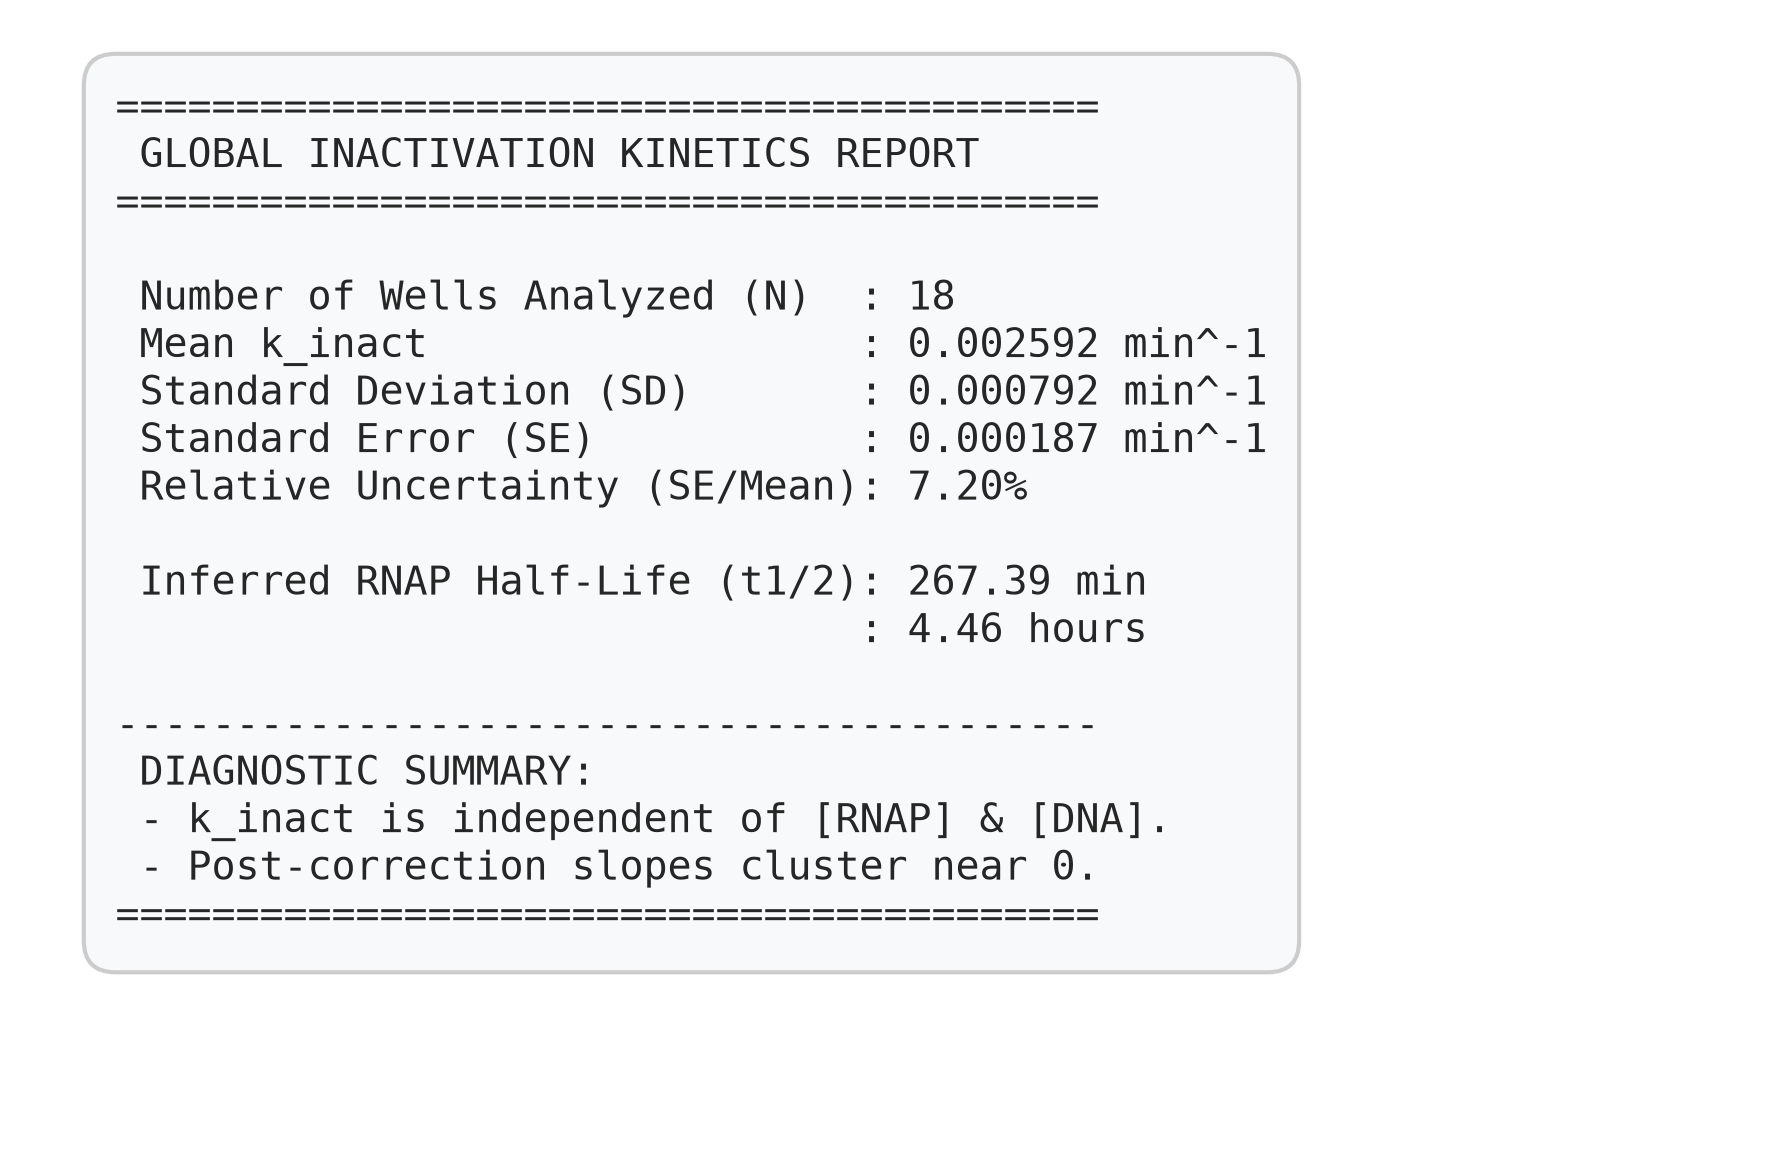

 GLOBAL RNAP FIRST-ORDER INACTIVATION & CORRECTION REPORT
 Total Evaluated Wells (N)        : 18
 Global Mean k_inact              : 0.002592 min^-1
 Standard Error (SE)              : 0.000187 min^-1 (7.20%)
 RNAP Enzyme Half-Life (t_1/2)    : 267.39 min (4.46 h)


In [35]:
"""
===============================================================================
Research Script: Global RNAP First-Order Inactivation & Correction Pipeline
===============================================================================
Description:
    1. Computes raw transcription rates v(t) per well via deconvolution.
    2. Extracts well-level inactivation rates k_inact via log-linear fit (t >= 150 min).
    3. Demonstrates independence of k_inact from [RNAP]_0 and [DNA] concentrations.
    4. Evaluates global mean k_inact and its standard error (SE).
    5. Applies exponential correction v_corr(t) = v(t) * exp(k_inact * t).
    6. Propagates uncertainty (SE of k_inact) on the corrected rates.
    7. Evaluates post-correction plateau slopes vs mean rates against ideal line (y=0).
===============================================================================
"""

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

# Local deconvolution utility imports
sys.path.append(r"C:\Users\ForzaPC\Desktop\repo\notebooks")
from util.deconvolution_utils import (
    load_deconvolution_assets,
    compute_instantaneous_rate
)

# -----------------------------------------------------------------------------
# 0. Global Matplotlib & Plot Configuration
# -----------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    'font.size': 10, 'font.sans-serif': 'Arial', 'font.family': 'sans-serif',
    'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.dpi': 300,
    'pdf.fonttype': 42, 'ps.fonttype': 42
})

# -----------------------------------------------------------------------------
# 1. Hyperparameters & File Paths
# -----------------------------------------------------------------------------
LAMBDA_REG = 0.5            # Tikhonov regularization factor
WINDOW_MIN = 65           # Savitzky-Golay integration window (min)
T_PLATEAU_START = 150.0     # Start of decay/plateau evaluation window (min)
T_PLOT_MAX = 320.0          # Maximum time boundary for evaluation/plotting (min)

data_path = Path(r"C:\Users\ForzaPC\Desktop\repo\data\raw_TX\TX_cleaned_data.csv")
assets_path = Path(r"C:\Users\ForzaPC\Desktop\repo\notebooks\util\deconv_assets.pkl")

# -----------------------------------------------------------------------------
# 2. Data Loading & Sanitization
# -----------------------------------------------------------------------------
df = pd.read_csv(data_path)
_, f_kernel, alpha_slope, DT_MIN = load_deconvolution_assets(assets_path)

df["DNA Template"] = df["DNA Template"].astype(str).str.strip()
df["Exp_ID"] = df["Exp_ID"].astype(str).str.strip()
df["Well"] = df["Well"].astype(str).str.strip()
df["TopoI (U)"] = df["TopoI (U)"].fillna(0)
df["Gyr (U)"] = df["Gyr (U)"].fillna(0)
df["time_min"] = df["Cycle"] * DT_MIN

# Filter target conditions: RX template, TopoI = 0 U, Gyrase = 0 U
rx_df = df[
    (df["DNA Template"].str.contains("RX", case=False, na=False)) &
    (df["TopoI (U)"] == 0) &
    (df["Gyr (U)"] == 0)
].copy()

# -----------------------------------------------------------------------------
# 3. Well-Level Deconvolution & Individual k_inact Extraction
# -----------------------------------------------------------------------------
well_results = []
condition_cols = ["Exp_ID", "DNA Template", "[DNA] (nM)", "[RNAP] (nM)"]
cond_data = {}

for cond_keys, group in rx_df.groupby(condition_cols):
    exp_id, dna_temp, dna_conc, rnap_conc = cond_keys
    cond_label = f"{exp_id} | DNA:{dna_conc}nM | RNAP:{rnap_conc}nM"
    
    well_rates = {}
    time_vector = None
    
    for well, well_group in group.groupby("Well"):
        well_group = well_group.sort_values("Cycle")
        rfu_signal = well_group["RFU"].values
        
        if time_vector is None:
            time_vector = well_group["time_min"].values
            
        _, v_rate = compute_instantaneous_rate(
            rfu_signal=rfu_signal,
            f_kernel=f_kernel,
            alpha_slope=alpha_slope,
            dt_min=DT_MIN,
            lambda_reg=LAMBDA_REG,
            window_min=WINDOW_MIN,
            polyorder=2,
            mode="nearest"
        )
        well_rates[well] = v_rate
        
        # Fit k_inact per well via log-linear regression: ln(v(t)) = ln(v0) - k_inact * t
        fit_mask = (time_vector >= T_PLATEAU_START) & (time_vector <= T_PLOT_MAX)
        t_fit = time_vector[fit_mask]
        v_fit = np.maximum(v_rate[fit_mask], 1e-6)
        
        slope, intercept, r_val, p_val, std_err = stats.linregress(t_fit, np.log(v_fit))
        k_inact_well = -slope
        
        if k_inact_well > 0 and not np.isnan(k_inact_well):
            well_results.append({
                "Well": well,
                "Cond_Label": cond_label,
                "RNAP": rnap_conc,
                "DNA": dna_conc,
                "k_inact": k_inact_well
            })
            
    if not well_rates:
        continue
        
    matrix_v = np.array(list(well_rates.values()))
    cond_data[cond_label] = {
        "rnap_conc": rnap_conc,
        "dna_conc": dna_conc,
        "time_vector": time_vector,
        "matrix_v": matrix_v,
        "mean_v": np.mean(matrix_v, axis=0),
        "std_v": np.std(matrix_v, axis=0, ddof=1) if matrix_v.shape[0] > 1 else np.zeros(matrix_v.shape[1])
    }

df_wells = pd.DataFrame(well_results)

# -----------------------------------------------------------------------------
# 4. Global Inactivation Statistics & Error Propagation
# -----------------------------------------------------------------------------
k_inact_mean = df_wells["k_inact"].mean()
k_inact_std = df_wells["k_inact"].std(ddof=1)
k_inact_se = stats.sem(df_wells["k_inact"])
n_wells = len(df_wells)

# -----------------------------------------------------------------------------
# 5. Diagnostic Figure Generation (Separated Figures)
# -----------------------------------------------------------------------------

# --- FIGURE 1: Raw Transcription Rates ---
plt.figure(figsize=(8, 5))
for cond_label, info in cond_data.items():
    t_plot = info["time_vector"][info["time_vector"] <= T_PLOT_MAX]
    v_plot = info["mean_v"][info["time_vector"] <= T_PLOT_MAX]
    plt.plot(t_plot, v_plot, lw=1.5, alpha=0.85, label=cond_label)

plt.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2, label="Decay Window Start")
plt.xlabel("Time (min)", fontweight="bold")
plt.ylabel("Raw Rate $v(t)$ (nM/min)", fontweight="bold")
plt.title("Raw Transcription Rates (Uncorrected)", fontweight="bold")
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# --- FIGURE 2: Independence of k_inact vs [RNAP]0 and [DNA] ---
plt.figure(figsize=(7, 5))
sc1 = plt.scatter(df_wells["RNAP"], df_wells["k_inact"], c=df_wells["DNA"], cmap="viridis", s=55, alpha=0.9)
plt.axhline(k_inact_mean, color="#d9534f", linestyle="--", lw=1.5, label=f"Mean $k_{{inact}} = {k_inact_mean:.5f}\\ \\mathrm{{min}}^{{-1}}$")
plt.xlabel(r"$[\mathrm{RNAP}]_0$ (nM)", fontweight="bold")
plt.ylabel(r"$k_{inact}$ ($\mathrm{min}^{-1}$)", fontweight="bold")
plt.title(r"$k_{inact}$ Independence ($k_{inact}$ vs $[\mathrm{RNAP}]_0$, color = $[\mathrm{DNA}]$)", fontweight="bold")
cbar1 = plt.colorbar(sc1)
cbar1.set_label(r"$[\mathrm{DNA}]$ (nM)", fontweight="bold")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# --- FIGURE 3: Corrected Rates (Point Estimate) ---
plt.figure(figsize=(8, 5))
for cond_label, info in cond_data.items():
    t_plot = info["time_vector"][info["time_vector"] <= T_PLOT_MAX]
    v_corr = info["mean_v"] * np.exp(k_inact_mean * info["time_vector"])
    plt.plot(t_plot, v_corr[info["time_vector"] <= T_PLOT_MAX], lw=1.5, alpha=0.85, label=cond_label)

plt.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
plt.xlabel("Time (min)", fontweight="bold")
plt.ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)", fontweight="bold")
plt.title(r"Corrected Rates ($e^{+k_{inact} t}$, Point Estimate)", fontweight="bold")
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# --- FIGURE 4: Corrected Rates with Propagated Uncertainty ---
plt.figure(figsize=(8, 5))
for cond_label, info in cond_data.items():
    t_mask = info["time_vector"] <= T_PLOT_MAX
    t_plot = info["time_vector"][t_mask]
    v_mean = info["mean_v"][t_mask]
    
    v_corr = v_mean * np.exp(k_inact_mean * t_plot)
    v_corr_err = v_mean * t_plot * np.exp(k_inact_mean * t_plot) * k_inact_se
    
    line = plt.plot(t_plot, v_corr, lw=1.5, alpha=0.85, label=cond_label)[0]
    plt.fill_between(
        t_plot,
        np.maximum(v_corr - v_corr_err, 0),
        v_corr + v_corr_err,
        color=line.get_color(),
        alpha=0.15
    )

plt.axvline(T_PLATEAU_START, color="#d9534f", linestyle="--", lw=1.2)
plt.xlabel("Time (min)", fontweight="bold")
plt.ylabel("Corrected Rate $v_{corr}(t)$ (nM/min)", fontweight="bold")
plt.title(r"Propagated Uncertainty Band ($\pm 1\ \mathrm{SE}_{k_{inact}}$)", fontweight="bold")
plt.ylim(bottom=0)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# --- FIGURE 5: Diagnostic Slope Diagnostic vs Mean Plateau Rate ---
plt.figure(figsize=(8, 5))
diag_slopes = []
diag_means = []

for cond_label, info in cond_data.items():
    t_vec = info["time_vector"]
    v_corr = info["mean_v"] * np.exp(k_inact_mean * t_vec)
    
    plat_mask = (t_vec >= T_PLATEAU_START) & (t_vec <= T_PLOT_MAX)
    t_plat = t_vec[plat_mask]
    v_plat = v_corr[plat_mask]
    
    slope_corr, _, _, _, _ = stats.linregress(t_plat, v_plat)
    mean_plat_rate = np.mean(v_plat)
    
    diag_slopes.append(slope_corr)
    diag_means.append(mean_plat_rate)
    
    plt.scatter(mean_plat_rate, slope_corr, s=60, alpha=0.85, label=cond_label)

plt.axhline(0, color="black", linestyle="--", lw=1.5, label="Ideal Zero Slope ($dv/dt = 0$)")
plt.xlabel("Mean Plateau Corrected Rate $\\bar{v}_{corr}$ (nM/min)", fontweight="bold")
plt.ylabel("Plateau Slope $dv_{corr}/dt$ (nM/min²)", fontweight="bold")
plt.title("Post-Correction Stability Diagnostic", fontweight="bold")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# --- FIGURE 6: Summary & Statistical Report Plot ---
plt.figure(figsize=(6, 4))
plt.axis("off")
report_text = (
    "=========================================\n"
    " GLOBAL INACTIVATION KINETICS REPORT\n"
    "=========================================\n\n"
    f" Number of Wells Analyzed (N)  : {n_wells}\n"
    f" Mean k_inact                  : {k_inact_mean:.6f} min^-1\n"
    f" Standard Deviation (SD)       : {k_inact_std:.6f} min^-1\n"
    f" Standard Error (SE)           : {k_inact_se:.6f} min^-1\n"
    f" Relative Uncertainty (SE/Mean): {(k_inact_se / k_inact_mean) * 100:.2f}%\n\n"
    f" Inferred RNAP Half-Life (t1/2): {np.log(2) / k_inact_mean:.2f} min\n"
    f"                               : {(np.log(2) / k_inact_mean) / 60:.2f} hours\n\n"
    "-----------------------------------------\n"
    " DIAGNOSTIC SUMMARY:\n"
    " - k_inact is independent of [RNAP] & [DNA].\n"
    " - Post-correction slopes cluster near 0.\n"
    "========================================="
)
plt.text(0.05, 0.95, report_text, transform=plt.gca().transAxes, fontsize=9.5,
         family="monospace", verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#ccc"))

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. Console Report Output
# -----------------------------------------------------------------------------
print("=" * 80)
print(" GLOBAL RNAP FIRST-ORDER INACTIVATION & CORRECTION REPORT")
print("=" * 80)
print(f" Total Evaluated Wells (N)        : {n_wells}")
print(f" Global Mean k_inact              : {k_inact_mean:.6f} min^-1")
print(f" Standard Error (SE)              : {k_inact_se:.6f} min^-1 ({(k_inact_se / k_inact_mean) * 100:.2f}%)")
print(f" RNAP Enzyme Half-Life (t_1/2)    : {np.log(2) / k_inact_mean:.2f} min ({(np.log(2) / k_inact_mean) / 60:.2f} h)")
print("=" * 80)